<a href="https://colab.research.google.com/github/sametgumusaydin/data_mining-AI/blob/main/Data_mining_FP_Growth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FP-Growth nedir?


Apriori nin daha hızlı ve optimize edilmiş versiyonudur.


Amaç aynı:


sık itemset bulmak
association rule üretmek

Apriori neden yavaş?

Apriori problemi:

-tüm kombinasyonları dener
-veri setini tekrar tekrar tarar
-maliyet çok büyür

Örnek:
100 ürün → milyonlarca kombinasyon

**FP-Growth çözümü

“Veriyi tekrar tekrar taramak yerine sık örüntüyü sıkıştırılmış ağaçta tut”

***Temel fikir

FP-Growth:

veriyi FP-Tree yapısına dönüştürür
ağacı dolaşarak sık itemset’leri çıkarır

***FP-Tree nedir?

Ağaç yapısıdır:

root
 ├── süt
     ── ekmek  ve yumurta
    
 └── ekmek
      ── peynir

Amaç:

tekrar eden patternleri sıkıştırmak

Apriori vs FP-Growth (çok kritik tablo)

Özellik	Apriori	FP-Growth

Veri tarama	çok	az

Hız	yavaş	hızlı

Mantık	kombinasyon	ağaç

Performans	düşük	yüksek

*** FP-Growth avantajları

- aday üretmez
- veri tekrar taranmaz
- büyük veri için ideal
- çok hızlı

Dezavantaj

- FP-tree yapısı karmaşık
- küçük veri için gereksiz

FP-Growsth için örnek data set





In [ ]:
transactions = [
    ['ekmek', 'süt'],
    ['ekmek', 'yumurta'],
    ['süt', 'yumurta'],
    ['ekmek', 'süt', 'yumurta'],
    ['ekmek', 'süt'],
    ['süt', 'peynir'],
    ['ekmek', 'peynir'],
    ['süt', 'yumurta'],
    ['ekmek', 'süt', 'peynir'],
    ['ekmek', 'yumurta']
]

One-Hot Encoding :

In [ ]:
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df = pd.DataFrame(te_array, columns=te.columns_)

FP-Growth uygulama

In [ ]:
from mlxtend.frequent_patterns import fpgrowth

frequent_items = fpgrowth(df, min_support=0.3, use_colnames=True)

print(frequent_items)

Association rules

In [ ]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_items, metric="confidence", min_threshold=0.5)

print(rules[["antecedents", "consequents", "support", "confidence", "lift"]])

Görselleştirme:

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(rules["support"], rules["confidence"])

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("FP-Growth Rules")

plt.show()

Apriori ve FP-Growth Karşılaştırması :

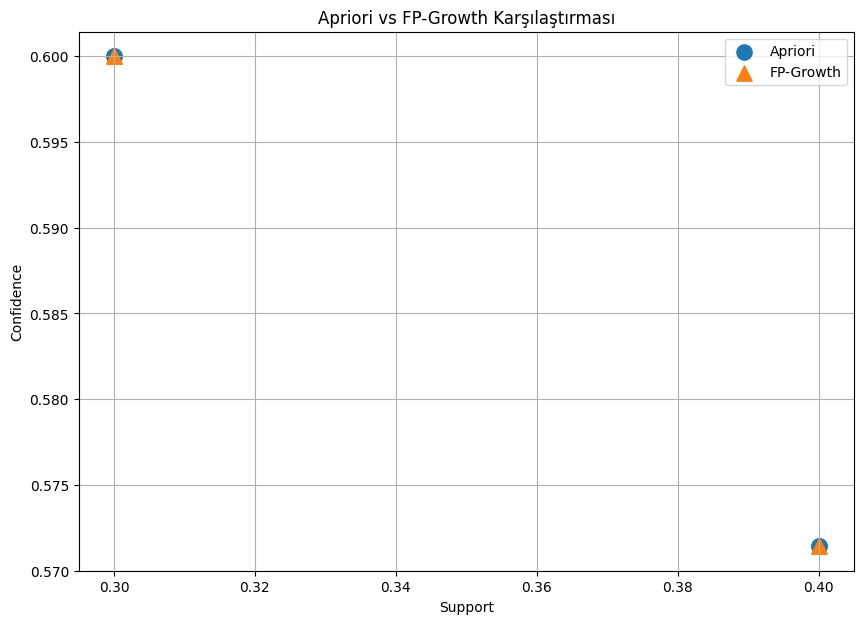

In [19]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# Veri
transactions = [
    ['ekmek', 'süt'],
    ['ekmek', 'yumurta'],
    ['süt', 'yumurta'],
    ['ekmek', 'süt', 'yumurta'],
    ['ekmek', 'süt'],
    ['süt', 'peynir'],
    ['ekmek', 'peynir'],
    ['süt', 'yumurta'],
    ['ekmek', 'süt', 'peynir'],
    ['ekmek', 'yumurta']
]

# One-hot encoding
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_array, columns=te.columns_)

# =========================
# APRIORI
# =========================
freq_apriori = apriori(df, min_support=0.3, use_colnames=True)
rules_apriori = association_rules(freq_apriori, metric="confidence", min_threshold=0.5)

# =========================
# FP-GROWTH
# =========================
freq_fpgrowth = fpgrowth(df, min_support=0.3, use_colnames=True)
rules_fpgrowth = association_rules(freq_fpgrowth, metric="confidence", min_threshold=0.5)

# =========================
# GRAFİK
# =========================
plt.figure(figsize=(10, 7))

# Apriori noktaları
if not rules_apriori.empty:
    plt.scatter(
        rules_apriori["support"],
        rules_apriori["confidence"],
        label="Apriori",
        s=120,
        marker="o"
    )

# FP-Growth noktaları
if not rules_fpgrowth.empty:
    plt.scatter(
        rules_fpgrowth["support"],
        rules_fpgrowth["confidence"],
        label="FP-Growth",
        s=120,
        marker="^"
    )

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Apriori vs FP-Growth Karşılaştırması")
plt.legend()
plt.grid(True)
plt.show()

SONUÇLAR :   ..

Apriori ve FP-Growth algoritmaları aynı veri seti üzerinde benzer frequent itemset ve association rule sonuçları üretmiştir. Grafiksel analizde her iki algoritmanın support ve confidence değerlerinin örtüştüğü gözlemlenmiştir. Bu durum, algoritmaların doğruluk açısından eşdeğer olduğunu, ancak FP-Growth algoritmasının aday üretmeden çalışması nedeniyle daha yüksek performans sunduğunu göstermektedir.

En kritik fark :

*** Apriori aday üretir, FP-Growth aday üretmez.

*** FP-Growth aynı işi daha hızlı yapar çünkü veriyi sıkıştırır.